# Machine Learning Practice: Exploratory Data Analysis & End-to-End Pipeline (The Titanic Case Study)

## 1. Data Collecting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
# Load Titanic dataset from local directory using pandas
file_path = 'https://raw.githubusercontent.com/mpfordreamer/library-practice/main/dataset/titanic.csv'
df = pd.read_csv(file_path)

# Convert all column names to lowercase so it matches our code!
df.columns = df.columns.str.lower()

print("Data loaded successfully! Shape:", df.shape)

Data loaded successfully! Shape: (418, 12)


## 2. Exploratory Data Analysis

In [4]:
# Display first 5 row data
df.head()

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
# Display the info of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  418 non-null    int64  
 1   survived     418 non-null    int64  
 2   pclass       418 non-null    int64  
 3   name         418 non-null    object 
 4   sex          418 non-null    object 
 5   age          332 non-null    float64
 6   sibsp        418 non-null    int64  
 7   parch        418 non-null    int64  
 8   ticket       418 non-null    object 
 9   fare         417 non-null    float64
 10  cabin        91 non-null     object 
 11  embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [4]:
# Display the number of NaN values in dataset
df.isna().sum()

passengerid      0
survived         0
pclass           0
name             0
sex              0
age             86
sibsp            0
parch            0
ticket           0
fare             1
cabin          327
embarked         0
dtype: int64

In [5]:
# Display the number of unique values
df.nunique()

passengerid    418
survived         2
pclass           3
name           418
sex              2
age             79
sibsp            7
parch            8
ticket         363
fare           169
cabin           76
embarked         3
dtype: int64

In [6]:
# Display the number of duplicate rows
print("Jumlah duplikasi: ", df.duplicated().sum())

Jumlah duplikasi:  0


In [7]:
# Display the statistical description of dataset
df.describe()

,passengerid,survived,pclass,age,sibsp,parch,fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


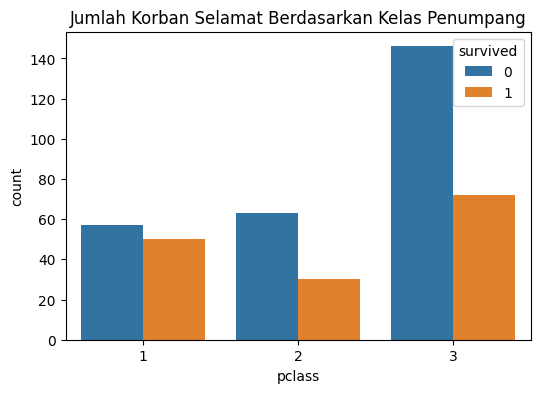

In [ ]:
# Tingkat Keselamatan berdasarkan Kelas Penumpang (Pclass)
plt.figure(figsize=(6, 4))
sns.countplot(df, x='pclass', hue='survived', palette='cool')
plt.title('Tingkat Keselamatan Berdasarkan Passenger Class')
plt.show()

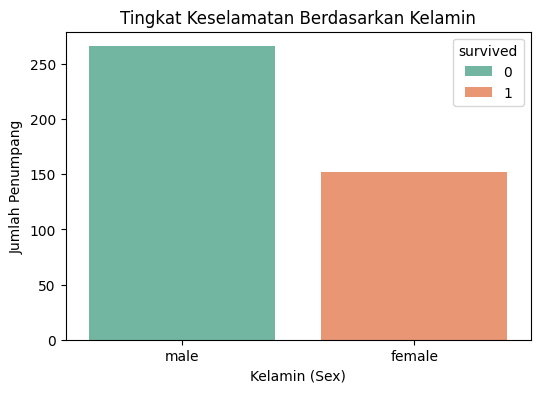

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(x='sex', hue='survived', data=df, palette='Set2')
plt.title('Tingkat Keselamatan Berdasarkan Kelamin')
plt.xlabel('Kelamin (Sex)')
plt.ylabel('Jumlah Penumpang')
plt.show()

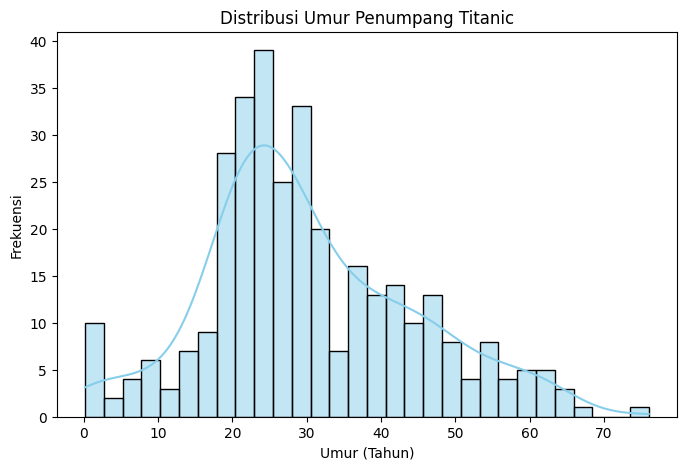

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', kde=True, bins=30, color='skyblue')
plt.title('Distribusi Umur Penumpang')
plt.xlabel('Umur (Tahun)')
plt.ylabel('Frekuensi')
plt.show()

C:\Users\dewam\AppData\Local\Temp\ipykernel_21700\2338706662.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='survived', y='fare', data=df, palette='pastel')


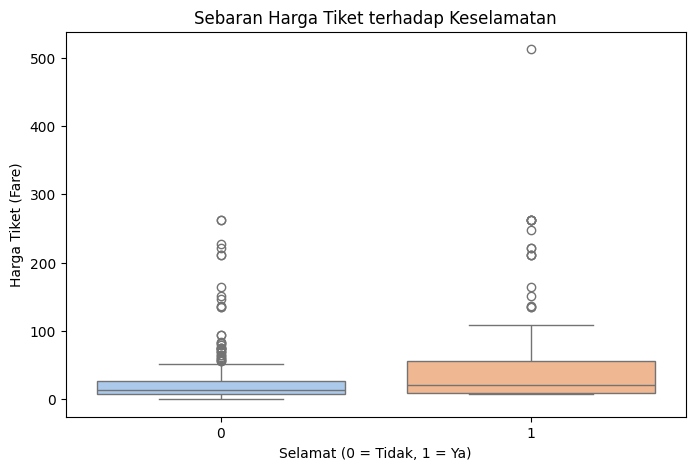

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='survived', y='fare', data=df, palette='pastel')
plt.title('Sebaran Harga Tiket terhadap Keselamatan')
plt.xlabel('Selamat (0 = Tidak, 1 = Ya)')
plt.ylabel('Harga Tiket (Fare)')
plt.show()

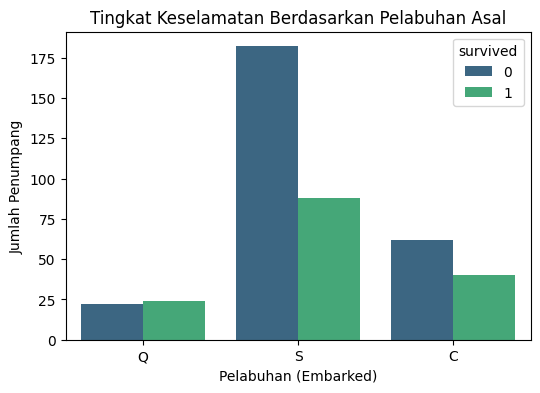

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x='embarked', hue='survived', data=df, palette='viridis')
plt.title('Tingkat Keselamatan Berdasarkan Pelabuhan Asal')
plt.xlabel('Pelabuhan (Embarked)')
plt.ylabel('Jumlah Penumpang')
plt.show()

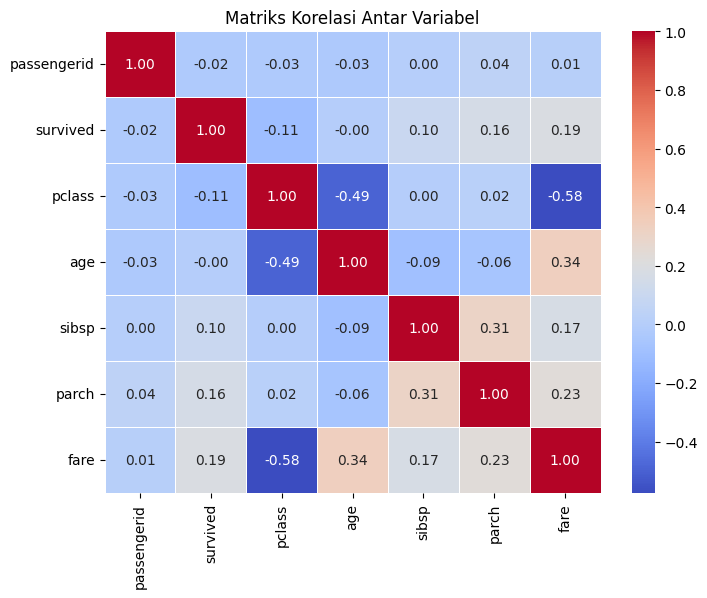

In [13]:
plt.figure(figsize=(8, 6))
numerics = df.select_dtypes(include=['number'])

sns.heatmap(numerics.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Antar Variabel')
plt.show()

## 3. Data Preprocessing

In [14]:
# Drop redundant or highly missing columns
df = df.drop(columns=['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male', 'alone'], errors='ignore')

# Handle missing values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [ ]:
# Encode categorical variables to numerical
df['sex'] = df['sex'].map({'male': 0, 'female': 1}) 
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})  # 0: Southampton, 1: Cherbourg, 2: Queenstown

In [ ]:
# Drop columns that won't be used for modeling
X = df.drop(columns=['survived', 'name', 'ticket', 'cabin', 'passengerid'], errors='ignore')
y = df['survived']

# Handle missing fare
X['fare'] = X['fare'].fillna(X['fare'].median())

# Train / test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Preprocessing completed. X_train shape:", X_train.shape)


Preprocessing completed. X_train shape: (334, 7)


## 4. Model Training

In [ ]:
# Initialize and train Logistic Regression model
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


## 5. Model Evaluation

In [19]:
# Predict on the test set
y_pred = model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.4f}\n")
print(f"Precision: {precision:.4f}\n")
print(f"Recall: {recall:.4f}\n")
print(f"F1-Score: {f1:.4f}\n")


Accuracy: 1.0000

Precision: 1.0000

Recall: 1.0000

F1-Score: 1.0000



In [20]:
# Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



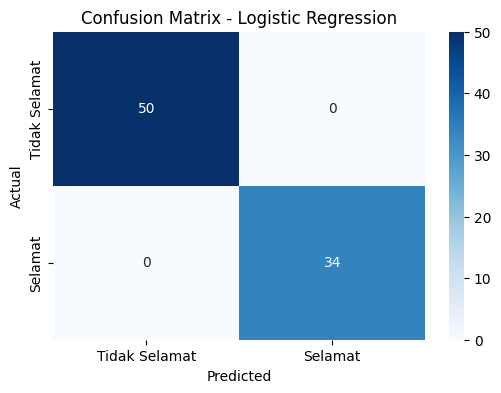

In [21]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Tidak Selamat', 'Selamat'], 
            yticklabels=['Tidak Selamat', 'Selamat'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()